In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"


In [2]:

import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import time
import pickle

from concurrent.futures import ProcessPoolExecutor, as_completed

import discretize
# from simpeg import dask
from simpeg import (
    maps,
    Data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils,
)
from simpeg.electromagnetics import time_domain as tdem
from simpeg.utils.solver_utils import get_default_solver

from simpeg.meta import MultiprocessingMetaSimulation, MetaSimulation

from parametric_ellipsoid import ParametricEllipsoid

Solver = get_default_solver()



In [3]:
rho_back = 1000
sigma_back = 1./rho_back

rho_target = 0.1
sigma_target = 1./rho_target

sigma_air = 1e-8

target_dips = np.r_[115] #, 45]
target_z = np.r_[-300, -150]

In [4]:
# rx_locs = np.loadtxt(f"{directory}/rx_locs.txt")
# rx_locs[:, 1] =
tx_height = 30

rx_x = (np.linspace(-500, 500, 101))[::5][2:-2]

rx_y = (np.linspace(-500, 500, 101))[::10][1::2]
# rx_y = np.r_[-80, -40, 0, 40, 80]

rx_z = tx_height

rx_locs = discretize.utils.ndgrid([rx_x, rx_y, rx_z])
rx_x

# rx_times = np.loadtxt(f"{directory}/rx_times.txt")
rx_times = np.logspace(np.log10(2e-5), np.log10(2e-3), 20)

In [5]:
rx_x

array([-400., -350., -300., -250., -200., -150., -100.,  -50.,    0.,
         50.,  100.,  150.,  200.,  250.,  300.,  350.,  400.])

In [6]:
rx_y

array([-400., -200.,    0.,  200.,  400.])

In [7]:
def diffusion_distance(sigma, t):
    return 1260*np.sqrt(t/sigma)

In [8]:
diffusion_distance(sigma_target, 8e-3)

np.float64(35.638181771801996)

In [9]:
diffusion_distance(sigma_back, 8e-3)

np.float64(3563.8181771801997)

In [10]:
base_cell_width = 20
domain_extent = 8000

n_base_cells = 2 ** int(
    np.ceil(np.log(domain_extent / base_cell_width) / np.log(2.0))
)  # needs to be powers of 2 for the tree mesh

h = [(base_cell_width, n_base_cells)]
mesh = discretize.TreeMesh([h, h, h], origin="CCC", diagonal_balance=True)

# refine near transmitters and receivers
mesh.refine_points(
    rx_locs, level=-1, padding_cells_by_level=[2, 2],
    finalize=False, diagonal_balance=True
)

# Refine core region of the mesh

bounding_points = np.array([
    [-500, rx_y.min(), target_z.min() - base_cell_width * 4],
    [500, rx_y.max(), 0],
])
mesh.refine_bounding_box(
    bounding_points, level=-1,
    diagonal_balance=True, finalize=False, padding_cells_by_level=[2, 2]
)

mesh.finalize()

In [11]:
mesh

OcTreeMesh: 0.06% filled

Level : Number of cells               Mesh Extent               Cell Widths    
-----------------------           min     ,     max            min   ,   max   
  3   :       448            ---------------------------   --------------------
  4   :       448         x:    -5120.0   ,   5120.0          20.0   ,   1280.0  
  5   :       332         y:    -5120.0   ,   5120.0          20.0   ,   1280.0  
  6   :       960         z:    -5120.0   ,   5120.0          20.0   ,   1280.0  
  7   :      1824      
  8   :      7392      
  9   :      69888     
-----------------------
Total :      81292

In [12]:
def dipping_target_indices(
    mesh, target_x_center, target_z_center, dip, target_thickness, target_xlim=None, target_ylim=None, target_zlim=None
):
    """
    add a dipping target to the model. For now assumes the target dips in the x-direction
    """
    slope = np.tan(-dip*np.pi/180)
    target_z = target_z_center + target_thickness / 2 * np.r_[-1, 1]

    z_bottom = (mesh.cell_centers[:, 0] - target_x_center) * slope + target_z.min()
    z_top = (mesh.cell_centers[:, 0] - target_x_center) * slope + target_z.max()

    indices = (
        (mesh.cell_centers[:, 2] >= z_bottom) &
        (mesh.cell_centers[:, 2] <= z_top)
    )

    if target_xlim is not None:
        indices = indices & (
            (mesh.cell_centers[:, 0] >= target_xlim.min()) &
            (mesh.cell_centers[:, 0] <= target_xlim.max())
        )
    if target_ylim is not None:
        indices = indices & (
            (mesh.cell_centers[:, 1] >= target_ylim.min()) &
            (mesh.cell_centers[:, 1] <= target_ylim.max())
        )
    if target_zlim is not None:
        indices = indices & (
            (mesh.cell_centers[:, 2] >= target_zlim.min()) &
            (mesh.cell_centers[:, 2] <= target_zlim.max())
        )
    return indices

In [13]:
models = {}

target_x = np.r_[-300, 300]
target_y = np.r_[-100, 100]
target_thickness = 200

# background model
background = np.ones(mesh.n_cells) * sigma_air
background[mesh.cell_centers[:, 2] < 0] = sigma_back
models["background"] = background

for dip in target_dips:
    model = background.copy()
    indices = dipping_target_indices(
        mesh, target_x_center=0, target_z_center=np.mean(target_z),
        target_thickness=target_thickness, dip=dip,
        target_xlim=target_x,
        target_ylim=target_y,
        target_zlim=target_z
    )
    model[indices] = sigma_target
    models[f"target_{dip}"] = model



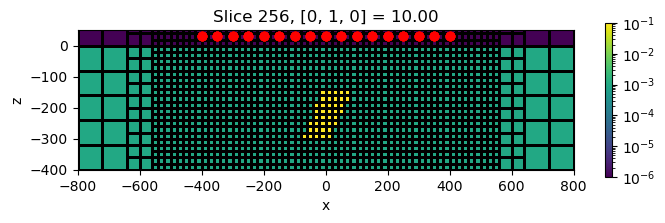

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 2))

plt.colorbar(
    mesh.plot_slice(
        models["target_115"],
        grid=True,
        normal="y",
        pcolor_opts={"norm":LogNorm(1e-6, 1e-1)},
        ax=ax)[0],
    ax=ax
)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])

ax.plot(rx_locs[:, 0], rx_locs[:, 2], "ro")
ax.set_aspect(1)

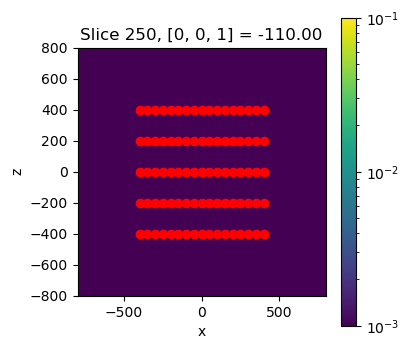

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

# mesh_local = mesh_list[-1]

plt.colorbar(
    mesh.plot_slice(
        models["target_115"],
        # grid=True,
        normal="z",
        pcolor_opts={"norm":LogNorm(1e-3, 1e-1)},
        ax=ax,
        ind=250
    )[0],
    ax=ax
)

xlim = 800*np.r_[-1, 1]
ax.set_xlim(xlim)
ax.set_ylim(xlim)

ax.plot(rx_locs[:, 0], rx_locs[:, 1], "ro")
ax.set_aspect(1)


In [16]:
source_list = []

for i in range(rx_locs.shape[0]):
    rx = tdem.receivers.PointMagneticFluxTimeDerivative(rx_locs[i, :], rx_times, orientation="z")
    src = tdem.sources.CircularLoop(
        receiver_list=[rx], location=rx_locs[i, :], orientation="z", radius=10,
        waveform=tdem.sources.StepOffWaveform()
    )
    source_list.append(src)

survey = tdem.Survey(source_list)

In [17]:
# set up local meshes
global_mesh = mesh
active_cells_map = maps.InjectActiveCells(global_mesh, global_mesh.cell_centers[:, 2]<0, value_inactive=np.log(1e-8))

refine_depth = 300
# def get_local_mesh(src):
mesh_list = []
x1 = np.mean(rx_locs[:, 0]) - (np.sum(global_mesh.h[0]) / 2)
x2 = np.mean(rx_locs[:, 1]) - (np.sum(global_mesh.h[1]) / 2)
x3 = np.mean(rx_locs[:, 2]) - (np.sum(global_mesh.h[2]) / 2)

for src in survey.source_list:
# src = survey.source_list[0]
    mesh_local = discretize.TreeMesh(global_mesh.h, origin=global_mesh.origin, diagonal_balance=True)
    refine_points = discretize.utils.ndgrid(
        np.r_[src.location[0]],
        np.r_[src.location[1]],
        np.linspace(-refine_depth, src.location[2], 40)
    )
    mesh_local.refine_points(
        refine_points,
        level=-1,
        padding_cells_by_level=[4, 2, 2],
        finalize=True,
        diagonal_balance=True
    )
    mesh_list.append(mesh_local)

    mesh_local.x0

In [18]:
mesh_local

OcTreeMesh,0.00% filled
Level,Number of cells
2,28
3,252
4,252
5,213
6,465
7,940
8,916
9,1632
Total,4698


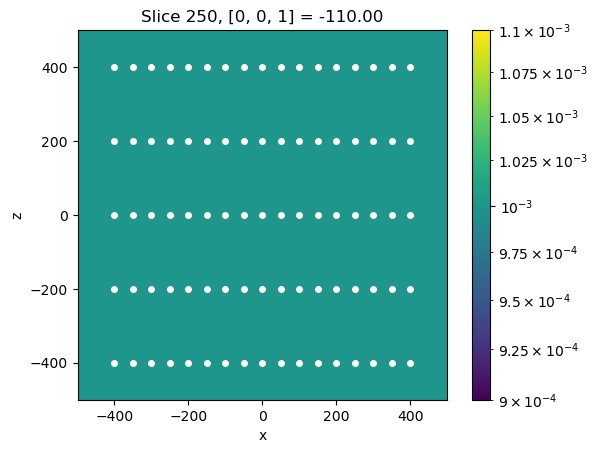

In [19]:
fig, ax = plt.subplots(1, 1)
plt.colorbar(
    mesh.plot_slice(
        models["target_115"], ax=ax, pcolor_opts={"norm":LogNorm()},
        normal="Z", ind=250
    )[0],
    ax=ax
)

ax.set_xlim(500*np.r_[-1, 1])
ax.set_ylim(500*np.r_[-1, 1])

ax.plot(rx_locs[:, 0], rx_locs[:, 1], "wo", ms=4)
ax.set_aspect(1)

In [20]:
nsteps = 20
time_steps = [
    # (1e-6, nsteps),
    (3e-6, nsteps),
    (1e-5, nsteps),
    (3e-5, nsteps),
    (1e-4, 20),
]


mappings = []
sims = []

for ii, local_mesh in enumerate(mesh_list):

    tile_map = maps.TileMap(global_mesh, active_cells_map.active_cells, local_mesh)
    mappings.append(tile_map)

    local_actmap = maps.InjectActiveCells(
        local_mesh,
        active_cells=tile_map.local_active,
        value_inactive=np.log(1e-8)
    )

    local_survey = tdem.Survey([survey.source_list[ii]])
    sims.append(tdem.simulation.Simulation3DElectricField(
            mesh=local_mesh,
            survey=local_survey,
            time_steps=time_steps,
            solver=Solver,
            sigmaMap=maps.ExpMap() * local_actmap
        )
    )


sim = MultiprocessingMetaSimulation(sims, mappings)

/home/lheagy/git/simpeg/simpeg/simpeg/meta/multiprocessing.py:229: UserWarning: The MetaSimulation class is a work in progress and might change in the future
  super().__init__(simulations, mappings)
/home/lheagy/git/simpeg/simpeg/simpeg/meta/multiprocessing.py:248: UserWarning: The MetaSimulation class is a work in progress and might change in the future
  sim_chunk = MetaSimulation(


/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/geoana/spatial.py:104: RuntimeWarning: invalid value encountered in multiply
  vec[..., 0] * np.cos(grid[..., 1]) - vec[..., 1] * np.sin(grid[..., 1]),
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site

In [21]:
model = np.log(models["target_115"][active_cells_map.active_cells])


In [22]:
%%time
sims[0].dpred(mappings[0] * model)

/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/pymatsolver/solvers.py:415: FutureWarning: In Future pymatsolver v0.4.0, passing a vector of shape (n, 1) to the solve method will return an array with shape (n, 1), instead of always returning a flattened array. This is to be consistent with numpy.linalg.solve broadcasting.
  return self.solve(val)


CPU times: user 2.29 s, sys: 45.8 ms, total: 2.34 s
Wall time: 2.33 s


array([-1.05439251e-07, -5.20626148e-08, -2.63833450e-08, -1.37417213e-08,
       -7.28845949e-09, -4.13405129e-09, -2.36830623e-09, -1.32016193e-09,
       -7.33993255e-10, -4.06712562e-10, -2.23837177e-10, -1.25222695e-10,
       -7.05645435e-11, -3.84090316e-11, -2.07382377e-11, -1.11479870e-11,
       -6.16007443e-12, -3.44193969e-12, -1.87015132e-12, -1.01627254e-12])

In [23]:
dobs = sim.dpred(model)
np.save("dobs-dipping.npy", dobs)

In [24]:
dobs_obj = Data(survey=survey, dobs=dobs)

In [25]:
n_times_invert = len(rx_times)
dobs_reshaped = dobs.reshape(len(rx_y), len(rx_x), n_times_invert)

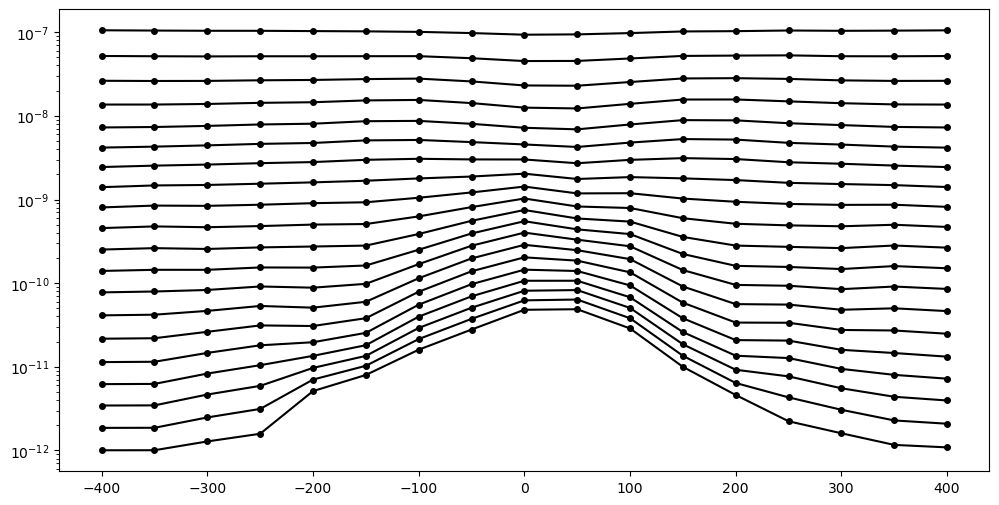

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.semilogy(rx_x, -dobs_reshaped[2, :, :], "-ok", ms=4);

In [27]:
relative_error = 0.05
noise_floor = 1e-12

In [28]:
len(rx_times)

20

In [29]:
times_invert = slice(10, None)
rx_times[times_invert]

array([0.00022577, 0.00028769, 0.0003666 , 0.00046714, 0.00059527,
       0.00075854, 0.00096659, 0.0012317 , 0.00156952, 0.002     ])

In [30]:
source_list_invert = []

for i in range(rx_locs.shape[0]):
    rx = tdem.receivers.PointMagneticFluxTimeDerivative(rx_locs[i, :], rx_times[times_invert], orientation="z")
    src = tdem.sources.CircularLoop(
        receiver_list=[rx], location=rx_locs[i, :], orientation="z", radius=10,
        waveform=tdem.sources.StepOffWaveform()
    )
    source_list_invert.append(src)

survey_invert = tdem.Survey(source_list_invert)

In [31]:
dobs_invert = dobs.reshape(len(rx_y), len(rx_x), n_times_invert)[:, :, times_invert].flatten()
data_invert = Data(
    survey_invert, dobs=dobs_invert,
    standard_deviation=np.abs(dobs_invert)*relative_error + noise_floor
)

In [32]:
param_mappings = []
param_sims = []

global_ellipsoid = ParametricEllipsoid(
    global_mesh,
    active_cells=active_cells_map.active_cells,
    # slopeFact=10,
)

for ii, local_mesh in enumerate(mesh_list):

    tile_map = maps.TileMap(global_mesh, active_cells_map.active_cells, local_mesh)

    local_actmap = maps.InjectActiveCells(
        local_mesh,
        active_cells=tile_map.local_active,
        value_inactive=np.log(1e-8)
    )
    param_mappings.append(tile_map * global_ellipsoid)

    local_survey = tdem.Survey([survey_invert.source_list[ii]])
    param_sims.append(tdem.simulation.Simulation3DElectricField(
            mesh=local_mesh,
            survey=local_survey,
            time_steps=time_steps,
            solver=Solver,
            sigmaMap=maps.ExpMap(local_mesh) * local_actmap
        )
    )

sim_parametric = MultiprocessingMetaSimulation(param_sims, param_mappings)

/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/geoana/spatial.py:104: RuntimeWarning: invalid value encountered in multiply
  vec[..., 0] * np.cos(grid[..., 1]) - vec[..., 1] * np.sin(grid[..., 1]),
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/geoana/spatial.py:104: RuntimeWarning: invalid value encountered in multiply
  vec[..., 0] * np.cos(grid[..., 1]) - vec[..., 1] * np.sin(grid[..., 1]),
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/geoana/spatial.py:104: RuntimeWarning: invalid value encountered in multiply
  vec[..., 0] * np.cos(grid[..., 1]) - vec[..., 1] * np.sin(grid[..., 1]),
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/geoana/spatial.py:104: RuntimeWarning: invalid value encountered in multiply
  vec[..., 0] * np.cos(grid[..., 1]) - vec[..., 1] * np.sin(grid[..., 1]),
/home/lheagy/miniforge3/envs/py311/lib/python3.11/site-packages/geoana/spatial.py:104: RuntimeWarning: invalid value encountered in mult

In [33]:
# p_0, rx, ry, rz, phix, phiy, phiz, x_0, y_0, z_0, p_1, a
parametric_model = np.r_[
    np.log(sigma_back), 100, 100, 300, 0, 0, 0, 0, 0, -200, np.log(sigma_target), 2
]

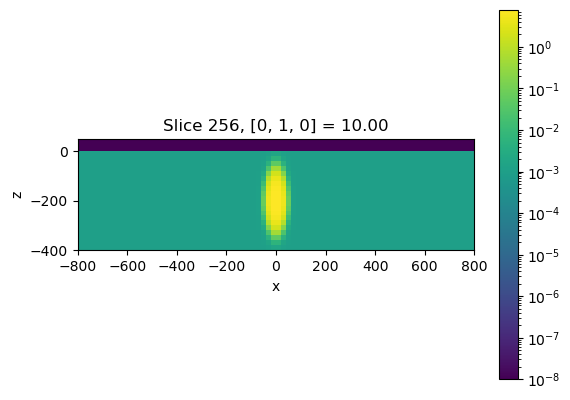

In [34]:
fig, ax = plt.subplots(1, 1)
plt.colorbar(
    mesh.plot_slice(
        maps.ExpMap()*active_cells_map*global_ellipsoid * parametric_model, normal="y", ax=ax,
        pcolor_opts={"norm":LogNorm()}
        )[0],
    ax=ax
)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])
ax.set_aspect(1)

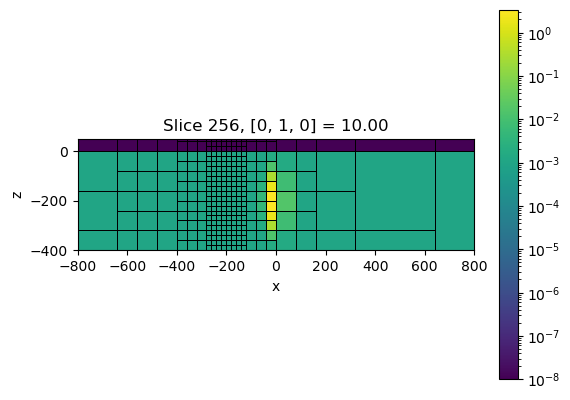

In [35]:
ind = 38
local_mesh = mesh_list[ind]
local_sim = param_sims[ind]
local_mapping = param_mappings[ind]

fig, ax = plt.subplots(1, 1)
plt.colorbar(local_mesh.plot_slice(
    local_sim.sigmaMap * local_mapping * parametric_model, normal="y", pcolor_opts={"norm":LogNorm()},
    ax=ax,
    # grid=True,
    grid_opts={"color":"k", "lw":0.5},
)[0], ax=ax)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])
ax.set_aspect(1)

In [36]:
dpred_parametric = sim_parametric.dpred(parametric_model)

In [37]:
n_times_invert = len(rx_times[times_invert])
dpred_parametric_reshaped = dpred_parametric.reshape(len(rx_y), len(rx_x), n_times_invert)

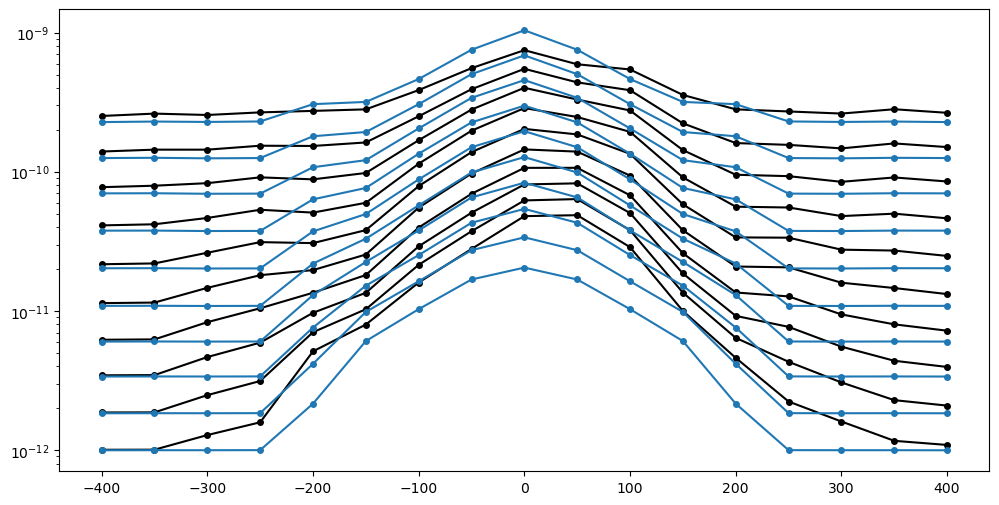

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ind = 2
ax.semilogy(rx_x, -dobs_reshaped[ind, :, times_invert], "-ok", ms=4);
ax.semilogy(rx_x, -dpred_parametric_reshaped[ind, :, :], "-oC0", ms=4);

In [39]:
dmis = data_misfit.L2DataMisfit(simulation=sim_parametric, data=data_invert)
regmesh = discretize.TensorMesh([len(parametric_model)])
reg = regularization.Smallness(
    regmesh
)

In [40]:
# opt = optimization.InexactGaussNewton(maxIter=5, cg_maxiter=30)
# p_0, rx, ry, rz, phix, phiy, phiz, x_0, y_0, z_0, p_1, a

opt = optimization.ProjectedGNCG(
    maxIter=10,
    upper=np.hstack([11*[np.inf], [4]])
)
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt, beta=0)


/tmp/ipykernel_127002/3694641723.py:4: FutureWarning: The defaults for ProjectedGNCG will change in SimPEG 0.26.0. If you want to maintain the previous behavior, explicitly set 'cg_atol=1E-3' and 'cg_rtol=0.0'.
  opt = optimization.ProjectedGNCG(


In [41]:
# Defining a starting value for the trade-off parameter (beta) between the data
# misfit and the regularization.
save_iteration = directives.SaveOutputDictEveryIteration(
    saveOnDisk=True,
)
target_misfit = directives.TargetMisfit()

/home/lheagy/git/simpeg/simpeg/simpeg/directives/_directives.py:2113: FutureWarning: SaveEveryIteration.saveOnDisk has been deprecated, please use SaveEveryIteration.on_disk. It will be removed in version 0.26.0 of SimPEG.
  self.saveOnDisk = save_on_disk
/home/lheagy/git/simpeg/simpeg/simpeg/directives/_directives.py:2114: FutureWarning: SaveEveryIteration.saveOnDisk has been deprecated, please use SaveEveryIteration.on_disk. It will be removed in version 0.26.0 of SimPEG.
  on_disk = self.saveOnDisk


In [42]:
# The directives are defined as a list.
directives_list = [
    save_iteration,
    target_misfit,
]

# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

In [43]:
m0 = parametric_model.copy()

In [44]:
mopt_parametric = inv.run(m0)

INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 850.0



Running inversion with SimPEG v0.24.1.dev33+g42a5db944
'SaveOutputDictEveryIteration' will save your inversion progress as a dictionary to: '/home/lheagy/git/simpeg-research/2026-heagy-etal-aem/compact-conductor/InversionModel_2026-06-10-13-57_00.npz'
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  0.00e+00  3.01e+03  0.00e+00  3.01e+03                         0           inf          inf                
   1  0.00e+00  2.63e+03  6.30e-01  2.63e+03    1.92e+04      2      5        2.87e-04     5.49e+00              
   2  0.00e+00  2.27e+03  5.58e+00  2.27e+03    1.59e+04      2      5        5.95e-02     9.49e+02   Skip BFGS  
   3  0.00e+00  1.71e+03  7.42e+00  1.71e+03    1.32e+04      

In [45]:
mopt_parametric

array([-6.82703473e+00,  8.72458300e+01,  8.19110087e+01,  2.97550742e+02,
       -1.87528877e-01, -1.15140615e-01, -1.06666169e+00, -7.49900289e+00,
        3.96732605e+00, -2.09021100e+02,  3.87311279e+00,  4.00000000e+00])

In [46]:
dpred_reshaped = inv_prob.dpred.reshape(len(rx_y), len(rx_x), n_times_invert)

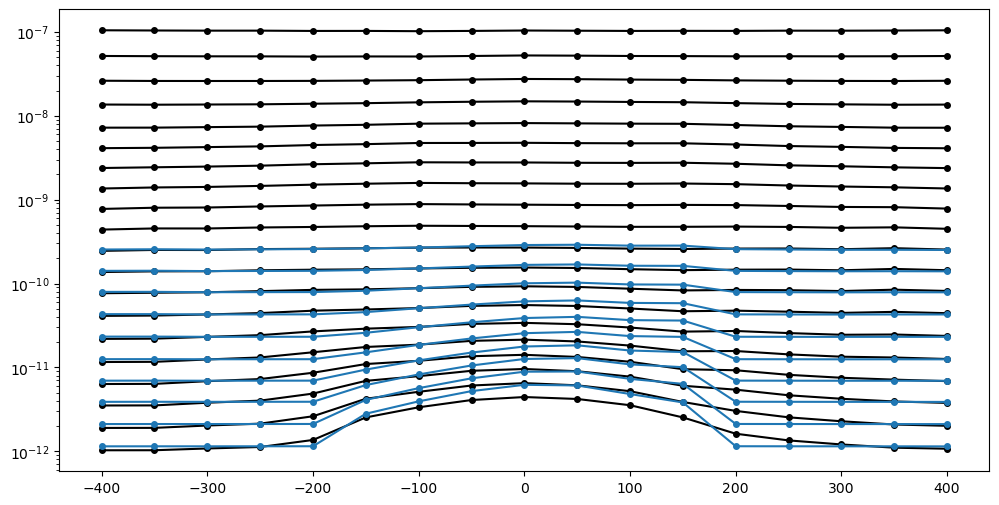

In [47]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ind = 3
ax.semilogy(rx_x, -dobs_reshaped[ind, :, :], "-ok", ms=4);
ax.semilogy(rx_x, -dpred_reshaped[ind, :, :], "-oC0", ms=4);

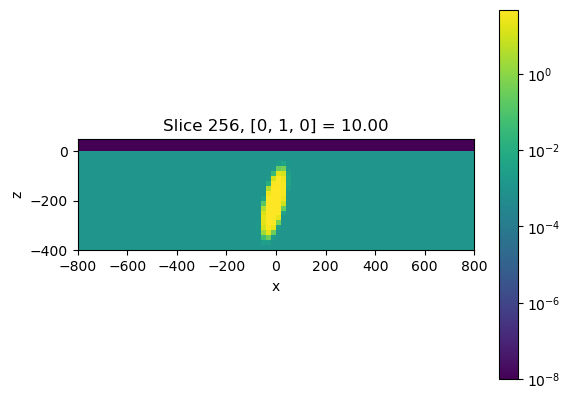

In [48]:
fig, ax = plt.subplots(1, 1)
plt.colorbar(
    mesh.plot_slice(
        maps.ExpMap()*active_cells_map*global_ellipsoid * mopt_parametric, normal="y", ax=ax,
        pcolor_opts={"norm":LogNorm()}
        )[0],
    ax=ax
)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])
ax.set_aspect(1)

In [49]:
data_invert_full = Data(
    survey, dobs=dobs,
    standard_deviation=np.abs(dobs)*relative_error + noise_floor
)

In [50]:
# set up an inversion now using the parametric as a reference model
dmis_full = data_misfit.L2DataMisfit(simulation=sim, data=data_invert_full)
reg = regularization.WeightedLeastSquares(
    global_mesh,
    active_cells = active_cells_map.active_cells,
    reference_model = global_ellipsoid * mopt_parametric
)


In [51]:
opt = optimization.InexactGaussNewton(maxIter=5)
inv_prob = inverse_problem.BaseInvProblem(dmis_full, reg, opt)


In [52]:
# Defining a starting value for the trade-off parameter (beta) between the data
# misfit and the regularization.
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=100, n_pw_iter=2)
cool_beta = directives.BetaSchedule(coolingFactor=2, coolingRate=4)
# Options for outputting recovered models and predicted data for each beta.
save_iteration = directives.SaveOutputDictEveryIteration(
    saveOnDisk=True,
)
target_misfit = directives.TargetMisfit()

In [53]:
# The directives are defined as a list.
directives_list = [
    starting_beta,
    cool_beta,
    save_iteration,
    target_misfit,
]

# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

In [54]:
m0 = np.ones(active_cells_map.active_cells.sum()) * np.log(sigma_back)

In [55]:
mrec = inv.run(m0)

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.24.1.dev33+g42a5db944


INFO: Directive TargetMisfit: Target data misfit is 1700.0


'SaveOutputDictEveryIteration' will save your inversion progress as a dictionary to: '/home/lheagy/git/simpeg-research/2026-heagy-etal-aem/compact-conductor/InversionModel_2026-06-10-14-16_0.npz'
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  6.73e-06  1.84e+04  3.61e+09  4.27e+04                                 
   1  6.73e-06  2.40e+04  1.45e+09  3.37e+04    3.44e+04      0              
   2  6.73e-06  1.29e+04  1.26e+09  2.14e+04    2.06e+04      0              
   3  6.73e-06  1.20e+04  9.79e+08  1.86e+04    1.94e+04      0   Skip BFGS  
   4  6.73e-06  1.22e+04  4.96e+08  1.55e+04    1.71e+04      0              
   5  3.37e-06  1.07e+04  4.72e+08  1.23e+04    5.60e+03      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 1.5366e+03 <= tolF*(1+|f0|)

In [ ]:
# out = np.load("InversionModel_2026-06-10-11-24_04.npz", allow_pickle=True)["arr_0"].item()

FileNotFoundError: [Errno 2] No such file or directory: 'InversionModel_2026-06-10-11-24_04.npz'

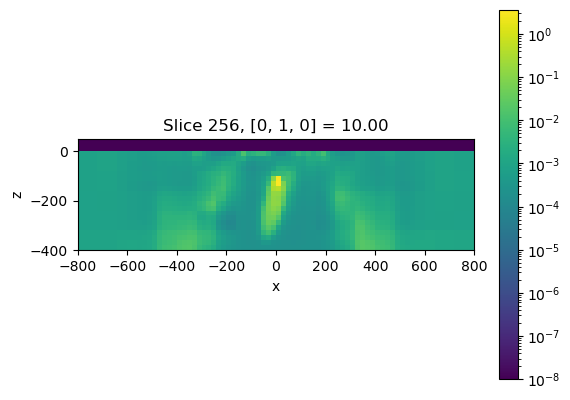

In [ ]:
fig, ax = plt.subplots(1, 1)
plt.colorbar(
    mesh.plot_slice(
        maps.ExpMap()*active_cells_map*out["m"], normal="y", ax=ax,
        pcolor_opts={"norm":LogNorm()}
        )[0],
    ax=ax
)

ax.set_xlim(800*np.r_[-1, 1])
ax.set_ylim(np.r_[-400, 50])
ax.set_aspect(1)